In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_excel(
    "../data/employee_attrition_scored.xlsx"
)

model = joblib.load(
    "../models/final_attrition_model.pkl"
)

print("Dataset shape:", df.shape)
print("Model loaded successfully!")

Dataset shape: (1470, 44)
Model loaded successfully!


In [3]:
X = df.drop(
    columns=[
        "Attrition",
        "Employee_ID",
        "Attrition_Probability",
        "Risk_Category"
    ],
    errors="ignore"
)

print("Feature shape:", X.shape)

Feature shape: (1470, 40)


In [4]:
preprocessor = model.named_steps["preprocessor"]
classifier = model.named_steps["classifier"]

print("Preprocessor:", type(preprocessor).__name__)
print("Classifier:", type(classifier).__name__)

Preprocessor: ColumnTransformer
Classifier: LogisticRegression


In [5]:
X_transformed = preprocessor.transform(X)

print("Original features:", X.shape[1])
print("Transformed features:", X_transformed.shape[1])

Original features: 40
Transformed features: 61


In [6]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))
print("\nFirst 20 features:")

for feature in feature_names[:20]:
    print(feature)

Number of feature names: 61

First 20 features:
num__Age
num__DailyRate
num__DistanceFromHome
num__Education
num__EnvironmentSatisfaction
num__HourlyRate
num__JobInvolvement
num__JobLevel
num__JobSatisfaction
num__MonthlyIncome
num__MonthlyRate
num__NumCompaniesWorked
num__PercentSalaryHike
num__PerformanceRating
num__RelationshipSatisfaction
num__StockOptionLevel
num__TotalWorkingYears
num__TrainingTimesLastYear
num__WorkLifeBalance
num__YearsAtCompany


In [7]:
clean_feature_names = []

for name in feature_names:
    name = name.replace("num__", "")
    name = name.replace("cat__", "")
    clean_feature_names.append(name)

print(clean_feature_names[:20])

['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany']


In [8]:
try:
    explainer = shap.TreeExplainer(classifier)
    shap_values = explainer.shap_values(X_transformed)

    print("Tree SHAP explainer created successfully!")

except Exception:
    explainer = shap.Explainer(
        classifier,
        X_transformed
    )

    shap_values = explainer.shap_values(
        X_transformed
    )

    print("General SHAP explainer created successfully!")

General SHAP explainer created successfully!


In [9]:
print("SHAP values shape:")

if isinstance(shap_values, list):
    print([value.shape for value in shap_values])
else:
    print(shap_values.shape)

SHAP values shape:
(1470, 61)


In [10]:
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
else:
    shap_values_positive = shap_values

print(
    "Positive-class SHAP shape:",
    shap_values_positive.shape
)

Positive-class SHAP shape: (1470, 61)


In [11]:
mean_abs_shap = np.abs(
    shap_values_positive
).mean(axis=0)

feature_importance = pd.DataFrame({
    "Feature": clean_feature_names,
    "Mean_SHAP_Importance": mean_abs_shap
})

feature_importance = feature_importance.sort_values(
    "Mean_SHAP_Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Mean_SHAP_Importance
31,Current_Role_Tenure_Ratio,0.425901
11,NumCompaniesWorked,0.424346
20,YearsInCurrentRole,0.394791
16,TotalWorkingYears,0.393851
26,OverTime_Flag,0.376169
7,JobLevel,0.312692
29,Workload_Stress_Score,0.300918
25,Engagement_Score,0.298884
49,JobRole_Laboratory Technician,0.294781
9,MonthlyIncome,0.276650


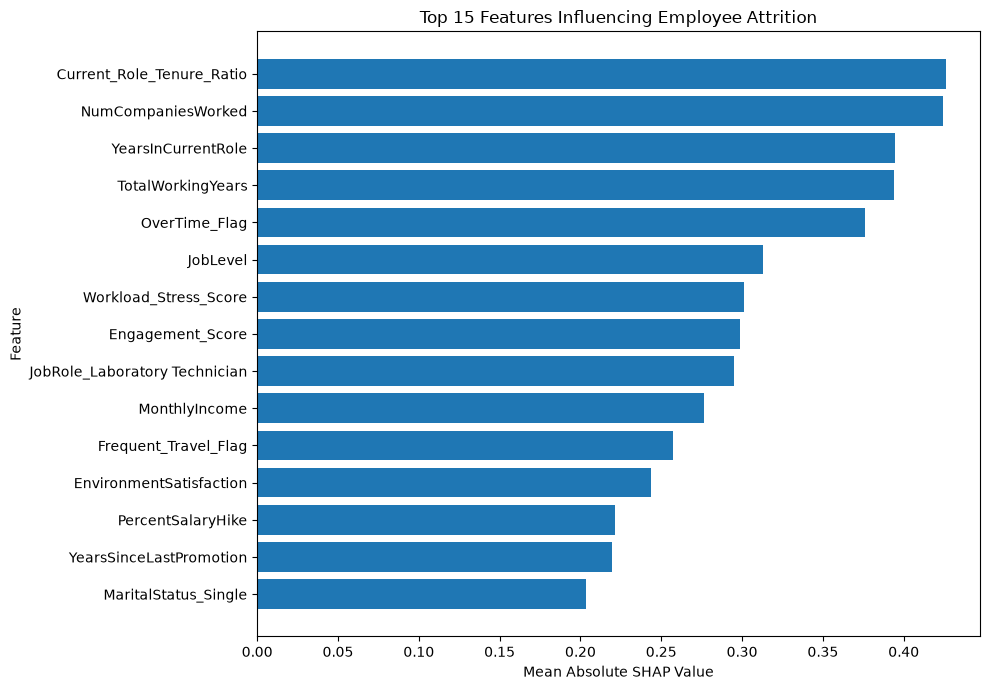

In [12]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Mean_SHAP_Importance"][::-1]
)

plt.title("Top 15 Features Influencing Employee Attrition")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

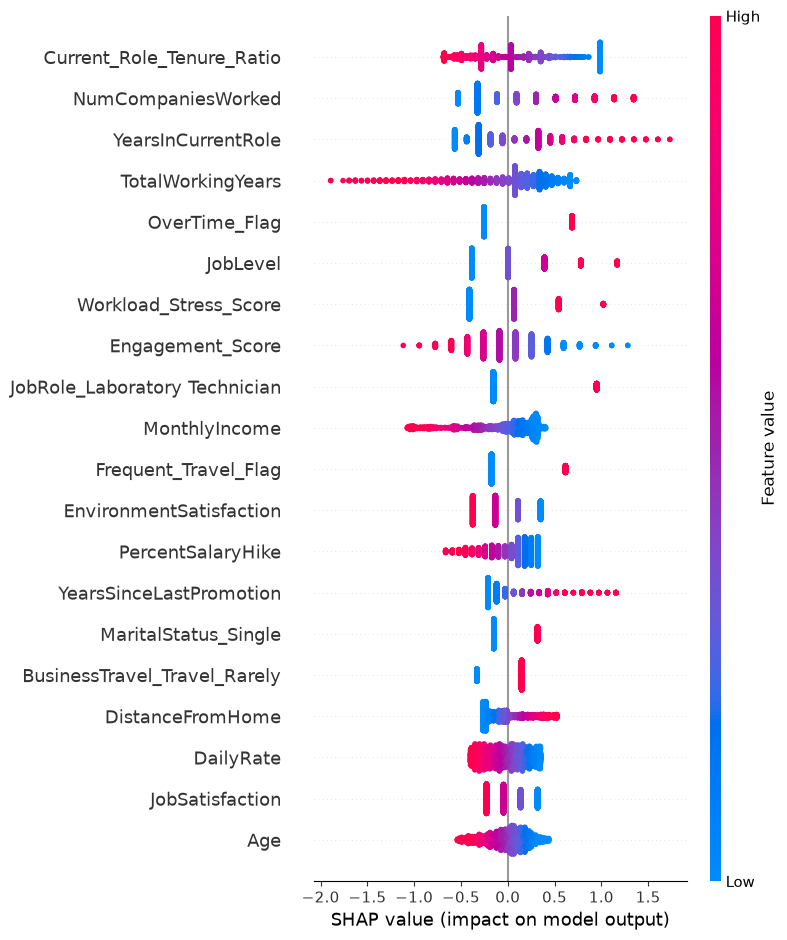

In [13]:
shap.summary_plot(
    shap_values_positive,
    X_transformed,
    feature_names=clean_feature_names,
    show=True
)

In [14]:
employee_index = 0

In [15]:
employee_index = 0

employee_id = df.loc[
    employee_index,
    "Employee_ID"
]

probability = df.loc[
    employee_index,
    "Attrition_Probability"
]

risk = df.loc[
    employee_index,
    "Risk_Category"
]

print("Employee:", employee_id)
print("Attrition Probability:", probability)
print("Risk Category:", risk)

Employee: EMP-0001
Attrition Probability: 0.9032
Risk Category: High


In [16]:
employee_shap = shap_values_positive[employee_index]

employee_explanation = pd.DataFrame({
    "Feature": clean_feature_names,
    "SHAP_Value": employee_shap
})

employee_explanation["Impact"] = np.where(
    employee_explanation["SHAP_Value"] > 0,
    "Increases Attrition Risk",
    "Decreases Attrition Risk"
)

employee_explanation["Absolute_SHAP"] = (
    employee_explanation["SHAP_Value"].abs()
)

employee_explanation = employee_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

employee_explanation.head(10)

,Feature,SHAP_Value,Impact,Absolute_SHAP
11,NumCompaniesWorked,1.136665,Increases Attrition Risk,1.136665
26,OverTime_Flag,0.686205,Increases Attrition Risk,0.686205
25,Engagement_Score,0.425065,Increases Attrition Risk,0.425065
17,TrainingTimesLastYear,0.376377,Increases Attrition Risk,0.376377
12,PercentSalaryHike,0.321667,Increases Attrition Risk,0.321667
58,MaritalStatus_Single,0.317682,Increases Attrition Risk,0.317682
18,WorkLifeBalance,0.281701,Increases Attrition Risk,0.281701
2,DistanceFromHome,-0.263553,Decreases Attrition Risk,0.263553
38,Department_Sales,0.239339,Increases Attrition Risk,0.239339
8,JobSatisfaction,-0.227842,Decreases Attrition Risk,0.227842


In [17]:
risk_increasing = (
    employee_explanation[
        employee_explanation["SHAP_Value"] > 0
    ]
    .head(5)
)

risk_increasing[
    [
        "Feature",
        "SHAP_Value"
    ]
]

,Feature,SHAP_Value
11,NumCompaniesWorked,1.136665
26,OverTime_Flag,0.686205
25,Engagement_Score,0.425065
17,TrainingTimesLastYear,0.376377
12,PercentSalaryHike,0.321667


In [18]:
risk_decreasing = (
    employee_explanation[
        employee_explanation["SHAP_Value"] < 0
    ]
    .sort_values(
        "SHAP_Value",
        ascending=True
    )
    .head(5)
)

risk_decreasing[
    [
        "Feature",
        "SHAP_Value"
    ]
]

,Feature,SHAP_Value
2,DistanceFromHome,-0.263553
8,JobSatisfaction,-0.227842
21,YearsSinceLastPromotion,-0.210431
1,DailyRate,-0.187325
27,Frequent_Travel_Flag,-0.173826


In [19]:
def create_reason_code(feature, direction):
    feature = feature.replace("_Yes", "")
    feature = feature.replace("_No", "")
    feature = feature.replace("_", " ")

    if direction == "increase":
        return f"{feature} is contributing to higher attrition risk"
    else:
        return f"{feature} is contributing to lower attrition risk"

In [20]:
risk_reasons = []

for _, row in risk_increasing.iterrows():
    risk_reasons.append(
        create_reason_code(
            row["Feature"],
            "increase"
        )
    )

print("Top Risk Factors:")
for reason in risk_reasons:
    print("-", reason)

Top Risk Factors:
- NumCompaniesWorked is contributing to higher attrition risk
- OverTime Flag is contributing to higher attrition risk
- Engagement Score is contributing to higher attrition risk
- TrainingTimesLastYear is contributing to higher attrition risk
- PercentSalaryHike is contributing to higher attrition risk


In [21]:
def explain_employee(index):
    probability = df.loc[
        index,
        "Attrition_Probability"
    ]

    risk = df.loc[
        index,
        "Risk_Category"
    ]

    shap_values_employee = shap_values_positive[index]

    explanation = pd.DataFrame({
        "Feature": clean_feature_names,
        "SHAP_Value": shap_values_employee
    })

    explanation["Absolute_SHAP"] = (
        explanation["SHAP_Value"].abs()
    )

    explanation = explanation.sort_values(
        "Absolute_SHAP",
        ascending=False
    )

    increasing = explanation[
        explanation["SHAP_Value"] > 0
    ].head(5)

    decreasing = explanation[
        explanation["SHAP_Value"] < 0
    ].sort_values(
        "SHAP_Value"
    ).head(5)

    return {
        "probability": probability,
        "risk": risk,
        "increasing": increasing,
        "decreasing": decreasing
    }

In [22]:
result = explain_employee(0)

print("Probability:", result["probability"])
print("Risk:", result["risk"])

print("\nFactors Increasing Risk:")
print(result["increasing"][["Feature", "SHAP_Value"]])

print("\nFactors Decreasing Risk:")
print(result["decreasing"][["Feature", "SHAP_Value"]])

Probability: 0.9032
Risk: High

Factors Increasing Risk:
                  Feature  SHAP_Value
11     NumCompaniesWorked    1.136665
26          OverTime_Flag    0.686205
25       Engagement_Score    0.425065
17  TrainingTimesLastYear    0.376377
12      PercentSalaryHike    0.321667

Factors Decreasing Risk:
                    Feature  SHAP_Value
2          DistanceFromHome   -0.263553
8           JobSatisfaction   -0.227842
21  YearsSinceLastPromotion   -0.210431
1                 DailyRate   -0.187325
27     Frequent_Travel_Flag   -0.173826


In [23]:
feature_importance.to_csv(
    "../data/shap_feature_importance.csv",
    index=False
)

print("SHAP feature importance saved!")

SHAP feature importance saved!


In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from pathlib import Path

BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"
MODEL_DIR = BASE_DIR / "models"

print("Base directory:", BASE_DIR)
print("Data directory:", DATA_DIR)
print("Model directory:", MODEL_DIR)

Base directory: c:\Users\yashw\OneDrive\Desktop\employee_attrition_prediction
Data directory: c:\Users\yashw\OneDrive\Desktop\employee_attrition_prediction\data
Model directory: c:\Users\yashw\OneDrive\Desktop\employee_attrition_prediction\models


In [25]:
model_path = MODEL_DIR / "final_attrition_model.pkl"

model = joblib.load(model_path)

print("Model loaded successfully!")
print(model)

Model loaded successfully!
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'DailyRate',
                                                   'DistanceFromHome',
                                                   'Education',
                                                   'EnvironmentSatisfaction',
                                                   'HourlyRate',
                                                   'JobInvolvement', 'JobLevel',
                                                   'JobSatisfaction',
                                                   'MonthlyIncome',
                                                   'MonthlyRate',
                                                   'NumCompaniesWorked',
                                                   'PercentSalaryHike',
                                                   'PerformanceRating',
              

In [26]:
engineered_file = DATA_DIR / "employee_attrition_engineered.xlsx"

if engineered_file.exists():
    df = pd.read_excel(engineered_file)
else:
    df = pd.read_excel(DATA_DIR / "Palo Alto Networks.xlsx")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1470, 42)


In [27]:
print("Columns:")
print(df.columns.tolist())

print("\nAttrition distribution:")
print(df["Attrition"].value_counts())

Columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Employee_ID', 'Income_Experience_Ratio', 'Promotion_Delay_Ratio', 'Engagement_Score', 'OverTime_Flag', 'Frequent_Travel_Flag', 'Long_Distance_Flag', 'Workload_Stress_Score', 'Workload_Stress_Flag', 'Current_Role_Tenure_Ratio', 'Manager_Tenure_Ratio']

Attrition distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [28]:
X = df.drop(columns=["Attrition"], errors="ignore")

y = df["Attrition"]

if y.dtype == "object":
    y = y.map({
        "No": 0,
        "Yes": 1
    })

y = pd.to_numeric(
    y,
    errors="coerce"
)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Missing target values:", y.isna().sum())

X shape: (1470, 41)
y shape: (1470,)
Missing target values: 0


In [29]:
preprocessor = model.named_steps["preprocessor"]

classifier = model.named_steps["classifier"]

print("Preprocessor:", type(preprocessor).__name__)
print("Classifier:", type(classifier).__name__)

Preprocessor: ColumnTransformer
Classifier: LogisticRegression


In [30]:
X_transformed = preprocessor.transform(X)

print("Original features:", X.shape[1])
print("Transformed features:", X_transformed.shape[1])

Original features: 41
Transformed features: 61


In [31]:
feature_names = preprocessor.get_feature_names_out()

print("Number of feature names:", len(feature_names))

print("\nFirst 20 features:")
print(feature_names[:20])

Number of feature names: 61

First 20 features:
['num__Age' 'num__DailyRate' 'num__DistanceFromHome' 'num__Education'
 'num__EnvironmentSatisfaction' 'num__HourlyRate' 'num__JobInvolvement'
 'num__JobLevel' 'num__JobSatisfaction' 'num__MonthlyIncome'
 'num__MonthlyRate' 'num__NumCompaniesWorked' 'num__PercentSalaryHike'
 'num__PerformanceRating' 'num__RelationshipSatisfaction'
 'num__StockOptionLevel' 'num__TotalWorkingYears'
 'num__TrainingTimesLastYear' 'num__WorkLifeBalance' 'num__YearsAtCompany']


In [32]:
X_transformed_df = pd.DataFrame(
    X_transformed,
    columns=feature_names,
    index=X.index
)

X_transformed_df.head()

,num__Age,num__DailyRate,num__DistanceFromHome,num__Education,num__EnvironmentSatisfaction,num__HourlyRate,num__JobInvolvement,num__JobLevel,num__JobSatisfaction,num__MonthlyIncome,...,cat__JobRole_Manufacturing Director,cat__JobRole_Research Director,cat__JobRole_Research Scientist,cat__JobRole_Sales Executive,cat__JobRole_Sales Representative,cat__MaritalStatus_Divorced,cat__MaritalStatus_Married,cat__MaritalStatus_Single,cat__OverTime_No,cat__OverTime_Yes
0,0.436189,0.742851,-1.022219,-0.882152,-0.658710,1.399483,0.373564,-0.070114,1.153526,-0.118455,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
1,1.308196,-1.308655,-0.166088,-1.855332,0.260202,-0.220971,-1.048155,-0.070114,-0.647997,-0.303976,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,0.000185,1.418377,-0.899915,-0.882152,1.179114,1.301274,-1.048155,-0.986265,0.252765,-0.957491,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,-0.435818,1.465739,-0.777610,1.064209,1.179114,-0.466494,0.373564,-0.986265,0.252765,-0.781429,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-1.089823,-0.530927,-0.899915,-1.855332,-1.577622,-1.252169,0.373564,-0.986265,-0.647997,-0.661260,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [34]:
explainer = shap.LinearExplainer(
    classifier,
    X_transformed_df
)

print("SHAP LinearExplainer created successfully!")

SHAP LinearExplainer created successfully!


In [35]:
shap_values = explainer.shap_values(
    X_transformed_df
)

print("SHAP values calculated successfully!")
print("SHAP shape:", np.array(shap_values).shape)

SHAP values calculated successfully!
SHAP shape: (1470, 61)


In [36]:
shap_array = np.array(shap_values)

print("SHAP rows:", shap_array.shape[0])
print("SHAP features:", shap_array.shape[1])

print("Dataset rows:", X_transformed_df.shape[0])
print("Dataset features:", X_transformed_df.shape[1])

SHAP rows: 1470
SHAP features: 61
Dataset rows: 1470
Dataset features: 61


In [37]:
mean_abs_shap = np.abs(
    shap_array
).mean(axis=0)

shap_importance = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Absolute_SHAP": mean_abs_shap
})

shap_importance = (
    shap_importance
    .sort_values(
        "Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

shap_importance.head(20)

,Feature,Mean_Absolute_SHAP
0,num__Current_Role_Tenure_Ratio,0.425901
1,num__NumCompaniesWorked,0.424346
2,num__YearsInCurrentRole,0.394791
3,num__TotalWorkingYears,0.393851
4,num__OverTime_Flag,0.376169
5,num__JobLevel,0.312692
6,num__Workload_Stress_Score,0.300918
7,num__Engagement_Score,0.298884
8,cat__JobRole_Laboratory Technician,0.294781
9,num__MonthlyIncome,0.276650


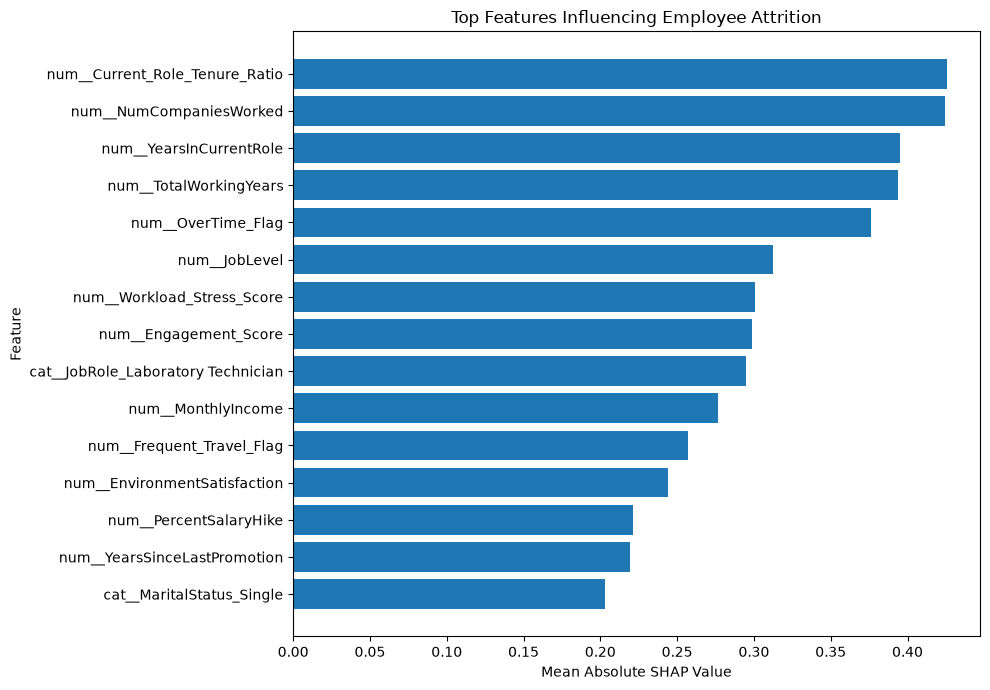

In [38]:
top_features = (
    shap_importance
    .head(15)
    .sort_values(
        "Mean_Absolute_SHAP"
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_features["Feature"],
    top_features["Mean_Absolute_SHAP"]
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Features Influencing Employee Attrition"
)

plt.tight_layout()

plt.show()

In [39]:
shap_output_path = (
    DATA_DIR / "shap_feature_importance.csv"
)

shap_importance.to_csv(
    shap_output_path,
    index=False
)

print(
    "SHAP feature importance saved successfully!"
)

print(
    shap_output_path
)

SHAP feature importance saved successfully!
c:\Users\yashw\OneDrive\Desktop\employee_attrition_prediction\data\shap_feature_importance.csv


In [40]:
employee_index = 0

employee_shap = pd.DataFrame({
    "Feature": feature_names,
    "SHAP_Value": shap_array[employee_index]
})

employee_shap["Absolute_SHAP"] = (
    np.abs(
        employee_shap["SHAP_Value"]
    )
)

employee_shap = (
    employee_shap
    .sort_values(
        "Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

employee_shap.head(15)

,Feature,SHAP_Value,Absolute_SHAP
0,num__NumCompaniesWorked,1.136665,1.136665
1,num__OverTime_Flag,0.686205,0.686205
2,num__Engagement_Score,0.425065,0.425065
3,num__TrainingTimesLastYear,0.376377,0.376377
4,num__PercentSalaryHike,0.321667,0.321667
5,cat__MaritalStatus_Single,0.317682,0.317682
6,num__WorkLifeBalance,0.281701,0.281701
7,num__DistanceFromHome,-0.263553,0.263553
8,cat__Department_Sales,0.239339,0.239339
9,num__JobSatisfaction,-0.227842,0.227842


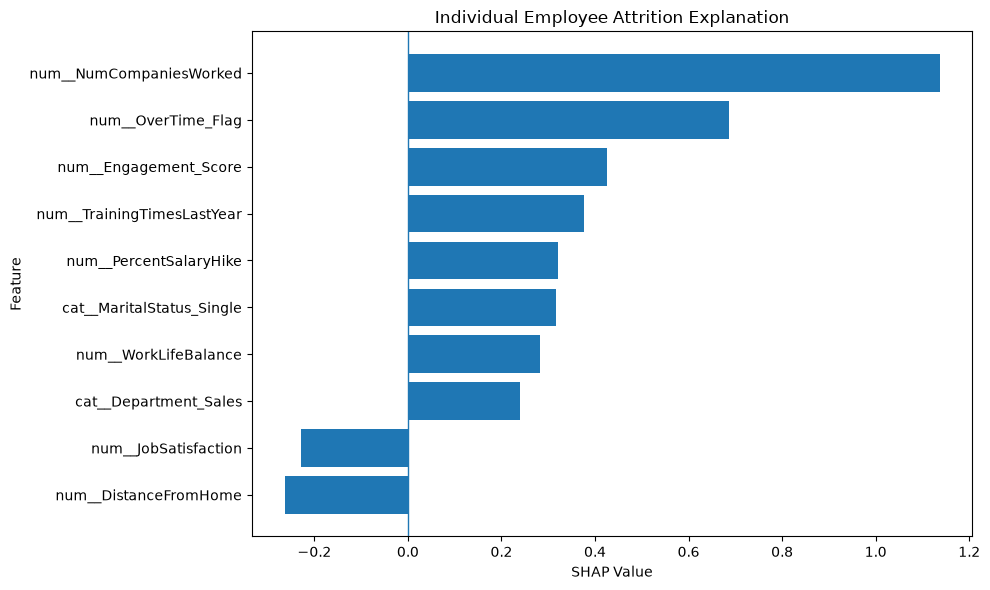

In [41]:
top_employee_features = (
    employee_shap
    .head(10)
    .sort_values(
        "SHAP_Value"
    )
)

plt.figure(
    figsize=(10, 6)
)

plt.barh(
    top_employee_features["Feature"],
    top_employee_features["SHAP_Value"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel(
    "SHAP Value"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Individual Employee Attrition Explanation"
)

plt.tight_layout()

plt.show()

In [42]:
positive_reasons = employee_shap[
    employee_shap["SHAP_Value"] > 0
].head(5)

negative_reasons = (
    employee_shap[
        employee_shap["SHAP_Value"] < 0
    ]
    .sort_values(
        "SHAP_Value"
    )
    .head(5)
)

print(
    "Factors increasing attrition risk:"
)

print(
    positive_reasons[
        [
            "Feature",
            "SHAP_Value"
        ]
    ].to_string(index=False)
)


print(
    "\nFactors reducing attrition risk:"
)

print(
    negative_reasons[
        [
            "Feature",
            "SHAP_Value"
        ]
    ].to_string(index=False)
)

Factors increasing attrition risk:
                   Feature  SHAP_Value
   num__NumCompaniesWorked    1.136665
        num__OverTime_Flag    0.686205
     num__Engagement_Score    0.425065
num__TrainingTimesLastYear    0.376377
    num__PercentSalaryHike    0.321667

Factors reducing attrition risk:
                     Feature  SHAP_Value
       num__DistanceFromHome   -0.263553
        num__JobSatisfaction   -0.227842
num__YearsSinceLastPromotion   -0.210431
              num__DailyRate   -0.187325
   num__Frequent_Travel_Flag   -0.173826


In [43]:
employee_explanation_path = (
    DATA_DIR / "employee_shap_explanations.csv"
)

employee_shap.to_csv(
    employee_explanation_path,
    index=False
)

print(
    "Employee SHAP explanation saved successfully!"
)

print(
    employee_explanation_path
)

Employee SHAP explanation saved successfully!
c:\Users\yashw\OneDrive\Desktop\employee_attrition_prediction\data\employee_shap_explanations.csv
